

**Clase Extra: Bajo el Capó de Pygame y la Percepción Humana**.

***

## El Dilema del Teclado: `event.get()` vs. `key.get_pressed()`

Ambos métodos leen la entrada del teclado, pero lo hacen de maneras fundamentalmente diferentes. La clave es entender la diferencia entre un **evento** y un **estado**.

### `pygame.event.get()` para lectura del evento keydown(se presionó tecla) y keyup(se liberó tecla)

* **¿Cómo funciona?:** Pygame mantiene una "cola de eventos", una lista de todas las cosas que han sucedido desde la última vez que se revisó: se movió el ratón, se hizo clic, se presionó una tecla, se soltó una tecla, etc. `for event in pygame.event.get():` recorre esa lista.
* **Analogía:** Imagina un cartero. El cartero te entrega una carta **una sola vez** en el momento exacto en que llega. `KEYDOWN` es la carta que dice "La tecla ESPACIO acaba de ser presionada". `KEYUP` es la carta que dice "La tecla ESPACIO acaba de ser soltada".
* **Pros ✅:**
    * **Precisión de Evento:** Es la única forma de capturar el **instante exacto** en que una tecla se presiona o se suelta.
    * **Ideal para Acciones Únicas:** Perfecto para acciones que deben ocurrir una sola vez por pulsación, como **saltar, disparar, abrir un menú o confirmar una opción**.
* **Contras ❌:**
    * **No es para acciones continuas:** Si mantienes presionada una tecla, el evento `KEYDOWN` solo se dispara una vez (o se repite a un ritmo lento definido por el sistema operativo, lo cual es inconsistente). No es bueno para el movimiento.

### `pygame.key.get_pressed()`

* **¿Cómo funciona?:** Este método no usa la cola de eventos. En cada fotograma que se llama, le pregunta directamente al hardware: "ej: si el teclado, ¿qué teclas están presionadas **ahora mismo**?". Devuelve una lista de estados (`True` o `False`) para cada tecla.
* **Analogía:** En lugar de esperar al cartero, en cada momento del día sales y revisas tu buzón. No sabes cuándo llegó la carta, solo sabes que **en este preciso instante, hay una carta (o no la hay)**.
* **Pros ✅:**
    * **Ideal para Acciones Continuas:** Perfecto para el **movimiento**. Mientras mantengas presionada la flecha derecha, en cada fotograma la comprobación devolverá `True`, permitiendo un movimiento suave y constante.
* **Contras ❌:**
    * **Ignora el "Cuándo":** No sabe si acabas de presionar la tecla o si llevas 10 segundos con ella presionada.
    * **No detecta liberaciones:** No hay forma de saber cuándo se soltó una tecla con este método.

### Veredicto: ¿Cuál es mejor?

**El mejor método es usar ambos, cada uno para lo que sirve.** Esta es la práctica profesional estándar.

* Usa el bucle de **eventos** (`KEYDOWN`) para acciones de un solo disparo como saltar o interactuar.
* Usa la comprobación de **estado** (`key.get_pressed()`) dentro del bucle principal para acciones continuas como caminar o correr.

***

## `blit`, `flip` y la Doble Memoria Gráfica

Esta es una de las partes más ingeniosas del renderizado de gráficos por computadora, las "zonas de memoria".

Imagina que eres un artista pintando un mural en una plaza pública. Si pintaras directamente sobre el mural final, la gente vería tus brochazos, las capas de pintura a medio secar, los borrones... un desastre parpadeante.

Para evitar esto, los juegos usan una técnica llamada **Doble Búfer (Double Buffering)**.



### Las Dos Zonas de Memoria

1.  **El Búfer Trasero (Back Buffer):** Esta en "zona de trabajo" o "lienzo oculto". Es un área en la memoria RAM (o en la VRAM de la tarjeta gráfica) que el jugador **no puede ver**. Aquí es donde ocurren todas las operaciones de dibujado de un fotograma:
    * `screen.fill()`: Es como aplicar una capa de pintura base a tu lienzo oculto, borrando el fotograma anterior.
    * `screen.blit()`: Significa "Block Image Transfer". Es el acto de "pegar" o "estampar" la imagen de un sprite (como tu jugador o un enemigo) sobre tu lienzo oculto. Haces `blit` para cada objeto del juego.

2.  **El Búfer Frontal (Front Buffer):** Esta es la imagen **finalizada y pulida** que el jugador está viendo en su monitor en este preciso instante. Es estática y no parpadea.

### `pygame.display.flip()`

* **¿Qué hace?:** `flip` es el momento mágico. Una vez que has terminado de dibujar todo en el Búfer Trasero, `flip` le dice a la tarjeta gráfica: "**Intercambia los búferes**".
* El Búfer Trasero, con tu nueva escena completamente dibujada, se convierte instantáneamente en el Búfer Frontal, mostrándose en el monitor.
* El antiguo Búfer Frontal (la imagen que se veía hasta hace un milisegundo) se convierte en el nuevo Búfer Trasero, listo para ser borrado y redibujado para el siguiente fotograma.

Este intercambio es tan rápido que es imperceptible, creando una ilusión de movimiento perfectamente fluida y sin parpadeos.

**¿Puede haber más de dos zonas?** Sí. Algunos motores gráficos usan **Triple Buffering**. Es como tener un lienzo en el monitor, uno en el que estás pintando y un tercero ya pintado y listo para ser mostrado. Esto puede suavizar aún más el rendimiento si el tiempo de dibujado de cada fotograma varía mucho, pero para Pygame, el modelo que debes tener en mente es el de Doble Búfer.

***

## FPS y la Interacción Humano-Computadora (HCI)

### ¿Qué son los FPS?

**FPS** significa **Frames Per Second** (Fotogramas por Segundo). Es la medida de cuántas imágenes únicas tu juego es capaz de dibujar en la pantalla cada segundo.
* **Analogía:** Un folioscopio (flipbook). Cada página es un fotograma. Los FPS son la velocidad a la que pasas las páginas.

### La Percepción Humana

* **Mínimo para ver movimiento:** El cerebro humano comienza a percibir una secuencia de imágenes estáticas como movimiento fluido alrededor de los **12-15 FPS**. Esto se ve entrecortado, como una animación stop-motion primitiva.
* **El estándar del cine:** Las películas se proyectan a **24 FPS**. Esto es suficiente para que el movimiento se vea natural y suave para una experiencia pasiva.
* **El mínimo para juegos:** **30 FPS** fue el estándar para consolas durante mucho tiempo. Se considera el mínimo aceptable para que un juego se sienta jugable, aunque puede no sentirse del todo responsivo.
* **El estándar moderno:** **60 FPS**. Esta es la meta para la mayoría de juegos de PC y consolas actuales. A 60 FPS, el movimiento es extremadamente suave y, lo que es más importante, los controles se sienten mucho más directos y responsivos.

### Tiempo de Reacción Humana

Este es un campo de la HCI. El tiempo que tardas en reaccionar a un estímulo visual (ver un enemigo y presionar un botón) no es instantáneo.

* El tiempo promedio de reacción visual simple de un humano es de aproximadamente **200 a 250 milisegundos (ms)**.
    * `1 segundo = 1000 milisegundos`

Pensemos qué significa esto en el contexto de los FPS:
* A 30 FPS, un fotograma dura `1000 / 30 = 33.3 ms`.
* A 60 FPS, un fotograma dura `1000 / 60 = 16.7 ms`.

En el tiempo que tardas en reaccionar (~250 ms), han pasado aproximadamente **7-8 fotogramas a 30 FPS**, o unos **15 fotogramas a 60 FPS**.

### Pros y Contras de Más FPS

* **Pros ✅:**
    * **Menor Latencia de Entrada (Input Lag):** Esta es la ventaja más importante. A 60 FPS, el juego "lee" tus acciones y actualiza la pantalla cada 16.7 ms. A 30 FPS, solo lo hace cada 33.3 ms. Esa diferencia, aunque pequeña, es perceptible y hace que el juego se sienta más "conectado" a tus acciones. En juegos competitivos, es una ventaja crucial.
    * **Suavidad Visual:** El movimiento es más nítido y menos borroso, lo que facilita el seguimiento de objetos rápidos en pantalla.
* **Contras ❌:**
    * **Coste de Rendimiento:** Dibujar 60 fotogramas por segundo requiere el doble de trabajo de CPU y GPU que dibujar 30. Necesitas un hardware más potente.
    * **Inconsistencia > Consistencia:** Un juego que fluctúa salvajemente entre 40 y 60 FPS se siente mucho peor que un juego que se mantiene bloqueado a unos sólidos y consistentes 30 FPS. Por eso, usar `clock.tick(60)` para establecer un techo estable es tan buena práctica.

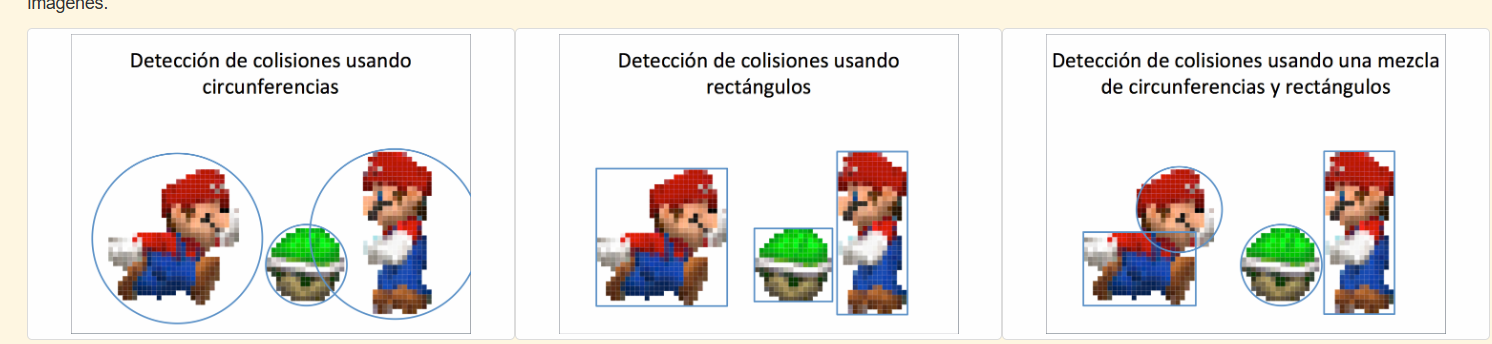

### Clase Extra: Detección de colisiones
La detección de colisiones es uno de los objetivos más imporantes de la interactividad en casi cualquier juego.

La detección de colisiones en Pygame se maneja principalmente a través de tres métodos:
la colisión de **rectángulos** (la más rápida y común), la colisión de **círculos** (ideal para objetos redondos y rotados), y la colisión por **máscaras** (la más precisa pero también la más lenta).
 La elección de uno u otro depende siempre de la precisión que necesites frente al rendimiento que quieras mantener.

-----

## Detección de Colisiones: El Arte de Chocar

En los videojuegos, nada existe realmente. Los personajes no "tocan" las paredes y las balas no "impactan" a los enemigos. Todo es una ilusión creada por la lógica, y la detección de colisiones es el núcleo de esa lógica. Es el sistema que le pregunta constantemente al juego: "¿Se están superponiendo estas dos formas?".

Cuando la respuesta es "sí", se desencadena una consecuencia: se pierde una vida, se suma un punto, se abre una puerta o se rompe un ladrillo. Sin colisiones, los juegos serían mundos fantasmales sin interacción.

-----

## Métodos de Detección de Colisiones en 2D

Existen varias formas de detectar si dos objetos chocan, cada una con un balance diferente entre **precisión** y **rendimiento**.

### 1\. Cajas Delimitadoras Alineadas a los Ejes (AABB) 📦

Este es el método más simple, rápido y común. Consiste en dibujar un rectángulo imaginario alrededor de cada objeto, alineado con los ejes X e Y de la pantalla. La colisión se comprueba viendo si estos dos rectángulos se superponen.

  * **Pros ✅:** **Extremadamente rápido.** La comprobación matemática es trivial (solo cuatro comparaciones por eje), por lo que puedes hacer miles de estas comprobaciones en cada fotograma sin afectar el rendimiento. Es el método principal que ofrece Pygame.
  * **Contras ❌:** **Impreciso.** No funciona bien para objetos que no son rectangulares o para objetos que rotan. Una nave espacial en diagonal tendrá una caja delimitadora mucho más grande que su forma real, provocando colisiones "injustas".

### 2\. Círculos Delimitadores 🟢

En lugar de un rectángulo, se dibuja un círculo imaginario alrededor de cada objeto, definido por un punto central y un radio. La colisión se comprueba midiendo la distancia entre los centros de los dos círculos. Si la distancia es menor que la suma de sus radios, están chocando.

  * **Pros ✅:** **Muy rápido** (casi tanto como AABB) y **perfecto para objetos que rotan**, ya que un círculo se ve igual desde cualquier ángulo. Ideal para pelotas, proyectiles redondos o naves espaciales vistas desde arriba.
  * **Contras ❌:** Solo es preciso para objetos que tienen una forma más o menos circular. Un personaje alto y delgado estaría muy mal representado por un círculo.

### 3\. Pixel Perfect (Usando Máscaras) 👾

Este es el método de máxima precisión. En lugar de usar una forma geométrica simple, se comparan las imágenes de los dos sprites píxel por píxel. La colisión ocurre solo si un **píxel no transparente** de un sprite se superpone con un **píxel no transparente** del otro.

  * **Pros ✅:** **Precisión absoluta.** La colisión es exactamente como la ve el jugador. Es perfecto para juegos de lucha donde un golpe debe registrarse en el puño y no en el aire que lo rodea.
  * **Contras ❌:** **Es costosos.** Comparar potencialmente miles de píxeles en cada fotograma es una operación computacionalmente muy costosa. Usarlo para todos los objetos de un juego lo haría injugable. A menudo, se usa como una segunda comprobación *después* de que una colisión AABB más barata ya haya sido detectada.

-----

## Detección de Colisiones en Pygame: Tu Caja de Herramientas

Pygame ofrece herramientas integradas y optimizadas para estos tres métodos.

### 1\. Colisión de Rectángulos (`Rect.colliderect` y `sprite.spritecollide`)

Esta es la forma más común en Pygame. Todos nuestros `GameObject` ya tienen un `self.rect`.

  ```python
  # Suponiendo que 'jugador' y 'enemigo' son sprites con un atributo .rect
  if jugador.rect.colliderect(enemigo.rect):
      print("¡Colisión rectangular detectada!")

  # O, de forma más potente, para comprobar un sprite contra un grupo entero:
  enemigos_golpeados = pygame.sprite.spritecollide(jugador, grupo_de_enemigos, True)
  # El 'True' al final hace que los enemigos golpeados se eliminen del grupo automáticamente.

  if enemigos_golpeados:
      print(f"¡El jugador ha chocado con {len(enemigos_golpeados)} enemigos!")
  ```

### 2\. Colisión de Círculos (`sprite.collide_circle`)

Para usar esto, tus sprites deben tener un atributo `radius`.

```python
# El sprite del jugador y del enemigo deben tener un atributo .radius
jugador.radius = 25
enemigo.radius = 30

if pygame.sprite.collide_circle(jugador, enemigo):
    print("¡Colisión circular detectada!")
```

### 3\. Colisión Pixel Perfect (`sprite.collide_mask`)

Este método requiere un paso previo: crear una "máscara" a partir de la imagen de cada sprite. La máscara es una representación eficiente de los píxeles opacos del sprite.

```python
# En la inicialización de tus sprites, después de cargar la imagen:
# Esto solo se hace una vez, no en el bucle principal.
jugador.mask = pygame.mask.from_surface(jugador.image)
enemigo.mask = pygame.mask.from_surface(enemigo.image)

# En el bucle principal del juego:
# Pygame primero hace una comprobación de rectángulos por eficiencia.
# Si los rectángulos chocan, entonces y solo entonces comprueba las máscaras.
if pygame.sprite.collide_mask(jugador, enemigo):
    print("¡Colisión PIXEL PERFECT detectada!")
```

-----

## Colisiones Complejas: Múltiples Hitboxes

A veces una sola forma (rectángulo o círculo) no es suficiente para representar a un objeto complejo, pero el Pixel Perfect es demasiado lento. La solución intermedia es usar **múltiples cajas de colisión (hitboxes)**.

Imagina un personaje de un juego de plataformas. Un solo rectángulo grande a su alrededor sería impreciso. En su lugar, podemos darle varios `Rect` más pequeños: uno para la cabeza, uno para el torso y uno para los pies.

```python
class Personaje(pygame.sprite.Sprite):
    def __init__(self, x, y):
        # ... (inicialización normal) ...
        self.image = # ...
        self.rect = self.image.get_rect(topleft=(x, y))

        # Creamos una lista de hitboxes relativas a la posición principal del sprite
        # (x_rel, y_rel, ancho, alto)
        self.hitbox_offsets = [
            (5, 0, 20, 20),  # Cabeza
            (0, 20, 30, 40), # Torso
        ]
        self.hitboxes = self._update_hitboxes()

    def _update_hitboxes(self):
        """Actualiza la posición de las hitboxes basándose en la posición principal."""
        lista_rects = []
        for offset in self.hitbox_offsets:
            rect = pygame.Rect(
                self.rect.x + offset[0],
                self.rect.y + offset[1],
                offset[2],
                offset[3]
            )
            lista_rects.append(rect)
        return lista_rects

    def update(self):
        # ... (lógica de movimiento del personaje) ...
        self.hitboxes = self._update_hitboxes() # ¡Crucial actualizar las hitboxes al moverse!

    def check_collision_with(self, otro_sprite):
        """Comprueba si alguna de nuestras hitboxes choca con otro sprite."""
        for hitbox in self.hitboxes:
            if hitbox.colliderect(otro_sprite.rect):
                return True
        return False

# En el bucle principal:
# personaje_complejo = Personaje(...)
# enemigo_simple = Enemigo(...)
if personaje_complejo.check_collision_with(enemigo_simple):
    print("¡Colisión con una de las múltiples hitboxes!")
```

Esta técnica te da mucha más precisión que un solo AABB sin el coste de rendimiento del Pixel Perfect, y es muy común en juegos de acción y plataformas.

En esta clase, introducimos un adversario. Esto nos obligará a gestionar diferentes "estados" del juego (estar jugando vs. haber perdido) y a programar nuestra primera y más simple forma de Inteligencia Artificial.

### Clase 5:
El Desafío - Enemigos, IA Simple y Estados del Juego

### Objetivo de la clase:
 Crear un objeto Enemigo que se mueva de forma autónoma. Implementar un "estado de juego" para diferenciar entre estar jugando y una pantalla de "Game Over". Programar la lógica para perder y reiniciar el juego.

Duración: 2 horas.

### Parte 1: El Enemigo Autónomo

1. El Plan: Un Enemigo con "Vida Propia"
Hasta ahora, todos los objetos o eran controlados por el jugador o estaban quietos.

Nuestro enemigo será el primer objeto con movimiento autónomo. No obedecerá al jugador.

Su "Inteligencia Artificial" será muy simple: se moverá en una dirección y, al chocar con una pared, rebotará y cambiará de sentido.

2. Creando la Clase Enemy
En nuestro archivo, junto a las clases Player y Collectible, añadimos la del enemigo.





        class Enemy:
            def __init__(self, x, y, ancho, alto, color):
                self.rect = pygame.Rect(x, y, ancho, alto)
                self.color = color
                # Damos al enemigo una velocidad en ambos ejes
                self.velocidad_x = 3
                self.velocidad_y = 3

            def update(self, ancho_pantalla, alto_pantalla):
                # Mover el enemigo
                self.rect.x += self.velocidad_x
                self.rect.y += self.velocidad_y

                # Lógica de rebote (IA Simple)
                if self.rect.left <= 0 or self.rect.right >= ancho_pantalla:
                    self.velocidad_x *= -1 # Invertir la dirección horizontal
                if self.rect.top <= 0 or self.rect.bottom >= alto_pantalla:
                    self.velocidad_y *= -1 # Invertir la dirección vertical
                    
            def dibujar(self, superficie):
                pygame.draw.rect(superficie, self.color, self.rect)

### Explicación del Código:

    __init__: Es similar a las otras clases, pero ahora guardamos una velocidad_x y velocidad_y que no dependen de la entrada del jugador.

    update(): ¡Este es el cerebro del enemigo!

    Primero, movemos su rect según su velocidad actual.

    Luego, comprobamos las colisiones con los bordes de la pantalla. self.rect.left es la coordenada X del borde izquierdo del rectángulo. Si es menor o igual a 0, ha chocado con la pared izquierda. self.rect.right es el borde derecho.

    self.velocidad_x *= -1: Este es un truco matemático genial. Al multiplicar la velocidad por -1, simplemente invertimos su signo. Si iba a la derecha (velocidad positiva), ahora irá a la izquierda (velocidad negativa), y viceversa.

3. Poniendo al Enemigo en el Juego
Ahora, vamos a crear una instancia del enemigo y a llamar a sus métodos update() y dibujar() en el bucle principal.



        # --- CREAMOS OBJETOS ---
        # ... (jugador, moneda)
        enemigo = Enemy(150, 150, 40, 40, (180, 50, 50)) # Un color rojo oscuro

        # --- BUCLE PRINCIPAL ---
        while ejecutando:
            # ... (input)

            # --- UPDATE ---
            jugador.mover(teclas)
            enemigo.update(ANCHO, ALTO) # ¡Llamamos al update del enemigo!
            # ... (colisión con la moneda)

            # --- RENDER ---
            PANTALLA.fill(AZUL_OSCURO)
            jugador.dibujar(PANTALLA)
            moneda.dibujar(PANTALLA)
            enemigo.dibujar(PANTALLA) # Dibujamos al enemigo
            
            # ... (el resto)
Prueba: Si ejecutas el código ahora, verás al cuadrado rojo oscuro moviéndose y rebotando por la pantalla por sí solo, ignorando por completo al jugador. ¡Felicidades, has programado tu primera IA!

### Parte 2: Estados del Juego y Consecuencias
1. El Problema: Una Sola Lógica para Todo
Ahora mismo, el juego siempre está "jugándose". No hay menú, ni pantalla de pausa, ni pantalla de derrota.

Necesitamos una forma de que nuestro motor sepa en qué "estado" se encuentra para comportarse de manera diferente.

Usaremos una simple variable que actuará como un interruptor: estado_juego.

2. Implementando el estado_juego
Vamos a definir dos estados: 'jugando' y 'game_over'. La lógica principal del juego (movimiento, colisiones) solo se ejecutará si estamos en el estado 'jugando'.


        import pygame

        from core.collectible import Collectible
        from core.enemy import Enemy
        from core.player import Player
        from utils.colors import ROJO, AZUL_OSCURO, BLANCO, NEGRO
        import random

        # 2. Inicializar pygame
        pygame.init()

        # 3. Definir el tamaño de la ventana
        ANCHO = 800
        ALTO = 600
        PANTALLA = pygame.display.set_mode((ANCHO, ALTO))

        # 4. Ponerle un título a la ventana
        pygame.display.set_caption('Segundo Juego')

        # --- CREAMOS EL OBJETO JUGADOR ---
        jugador = Player(ANCHO / 2 - 25, ALTO / 2 - 25, 50, 50, ROJO)
        enemigo = Enemy(150, 150, 40, 40, (180, 50, 50))  # Un color rojo oscuro
        fuente = pygame.font.Font(None, 36)
        # Creamos una instancia de nuestra nueva clase
        moneda = Collectible(100, 100, 30, 30, (255, 223, 0))  # Un color dorado
        reloj = pygame.time.Clock()  # Creamos un objeto Clock
        puntuacion = 0  # Nuestra variable para la puntuación
        estado_juego = 'jugando'


        # --- BUCLE PRINCIPAL ---
        ejecutando = True
        while ejecutando:
            # --- INPUT ---
            for evento in pygame.event.get():
                if evento.type == pygame.QUIT:
                    ejecutando = False

            # El código se divide según el estado del juego
            if estado_juego == 'jugando':
                # --- INPUT ---
                teclas = pygame.key.get_pressed()

                # --- UPDATE ---
                jugador.mover(teclas)
                enemigo.update(ANCHO, ALTO)

                # Colisión con moneda
                if jugador.rect.colliderect(moneda.rect):
                    puntuacion += 1
                    # Movemos la moneda a una nueva posición aleatoria
                    moneda.rect.x = random.randint(0, ANCHO - moneda.rect.width)
                    moneda.rect.y = random.randint(0, ALTO - moneda.rect.height)

                # ¡NUEVA COLISIÓN CON ENEMIGO!
                if jugador.rect.colliderect(enemigo.rect):
                    estado_juego = 'game_over'  # ¡Cambiamos el estado!

                # --- RENDER ---
                PANTALLA.fill(AZUL_OSCURO)
                jugador.dibujar(PANTALLA)
                texto_puntuacion = fuente.render(f"Puntuación: {puntuacion}", True, BLANCO)
                enemigo.dibujar(PANTALLA)  # Dibujamos al enemigo
                moneda.dibujar(PANTALLA)
                # 3. DIBUJAR EL TEXTO EN LA PANTALLA
                PANTALLA.blit(texto_puntuacion, (10, 10))  # Lo ponemos en la esquina sup. izq.

            elif estado_juego == 'game_over':
                # --- Lógica para la pantalla de Game Over ---
                PANTALLA.fill(NEGRO)  # Fondo negro para indicar derrota
                # Por ahora, la dejamos así. En el siguiente paso la completamos.


            pygame.display.flip()


            # --- CONTROL DE TIEMPO ---
            # Le decimos al reloj que espere lo necesario para que el bucle
            # no se ejecute más de 60 veces por segundo.

            reloj.tick(60)
            pygame.quit()



### Explicación:

Hemos envuelto toda la lógica del juego dentro de if estado_juego == 'jugando':.

Añadimos la colisión con el enemigo. En lugar de dar puntos, cambia el valor de estado_juego.

En cuanto estado_juego cambia a 'game_over', todo el bloque de "jugando" se ignora en el siguiente fotograma, y el juego se "congela".


### Parte 3: Pantalla de Game Over y Reinicio
1. Creando la Pantalla de Derrota
Vamos a usar nuestras habilidades para renderizar texto de la clase pasada para mostrar un mensaje de "Game Over".



        # ... (creamos fuente y fuente_grande)
        fuente = pygame.font.Font(None, 36)
        fuente_grande = pygame.font.Font(None, 72) # Una fuente más grande

        # ... (en el bucle, dentro del elif estado_juego == 'game_over':)

            elif estado_juego == 'game_over':
                PANTALLA.fill(NEGRO)
                
                # Renderizar textos
                texto_game_over = fuente_grande.render("GAME OVER", True, ROJO)
                texto_instruccion = fuente.render("Presiona ESPACIO para reiniciar", True, BLANCO)

                # Centrar los textos en la pantalla
                pos_game_over = texto_game_over.get_rect(center=(ANCHO / 2, ALTO / 2 - 50))
                pos_instruccion = texto_instruccion.get_rect(center=(ANCHO / 2, ALTO / 2 + 50))

                # Dibujar los textos
                PANTALLA.blit(texto_game_over, pos_game_over)
                PANTALLA.blit(texto_instruccion, pos_instruccion)

                # ¿Cómo reiniciamos? (siguiente paso)


### Explicación:

texto.get_rect(center=(x, y)): Este es un truco muy útil. Crea un Rect para nuestro texto y automáticamente ajusta su x e y para que el centro del texto quede en las coordenadas que le pasamos. ¡Perfecto para centrar!

2. La Lógica de Reinicio
¿Cómo volvemos a jugar? Al presionar la tecla (espacio), reiniciaremos todas las variables a su estado inicial.



        # ... (en el bucle, dentro del elif estado_juego == 'game_over':)
            
            # ... (código para dibujar los textos)

            # --- INPUT para reiniciar ---
            for evento in pygame.event.get():
                if evento.type == pygame.QUIT:
                    ejecutando = False
                # Si se presiona una tecla Y estamos en game_over
                if evento.type == pygame.KEYDOWN:
                    if evento.key == pygame.K_SPACE:
                        # Reiniciar todas las variables del juego
                        puntuacion = 0
                        jugador.rect.topleft = (50, 50) # Posición inicial
                        enemigo.rect.topleft = (random.randint(0, ANCHO-40), 0) # Posición aleatoria
                        estado_juego = 'jugando' # ¡Volvemos a jugar!

### Explicación:

Necesitamos un bucle de eventos también dentro del estado game_over para detectar el QUIT y el reinicio.

    evento.type == pygame.KEYDOWN: Este evento se dispara solo en el instante en que una tecla es presionada.

    evento.key == pygame.K_SPACE: Comprueba si la tecla presionada fue, específicamente, la barra espaciadora.

Cuando se cumple, reiniciamos todo: el jugador vuelve a su esquina, el enemigo a una nueva posición aleatoria, la puntuación a cero y, lo más importante, el estado_juego a 'jugando'.

### Cierre y Próximos Pasos
Resumen de Hoy: Nuestro motor ahora no solo maneja objetos controlados por el jugador, sino también objetos autónomos con IA. Más importante aún, hemos implementado un gestor de estados que nos permite tener un flujo de juego completo: jugar, perder y reiniciar.

Adelanto de la Clase 6: "Nuestro juego ya es funcional, pero es visualmente aburrido y silencioso. La próxima clase será sobre pulido y feedback al jugador. Aprenderemos a reemplazar nuestros cuadrados de colores por imágenes y sprites. También añadiremos efectos de sonido para cuando tomemos una moneda o chocamos con un enemigo. ¡Haremos que el juego se sienta vivo!"

### Tarea/Desafío:

Crea un segundo enemigo. Dale una velocidad y un color diferentes. Haz que la colisión con cualquiera de los dos provoque el "Game Over". (Pista: tendrás que crear una lista de enemigos y usar un bucle for para actualizarlos y comprobar las colisiones).

Haz que, al reiniciar, la moneda también cambie su posición a una nueva ubicación aleatoria, no a la que tenía cuando perdiste.




### Crear a clase Game

Damos un paso más en la construccion del motor, y movemos la lógica del main a una clase llamada Game.

    import random

    import pygame

    from core.collectible import Collectible
    from core.enemy import Enemy
    from core.player import Player
    from utils.colors import ROJO, AZUL_OSCURO, BLANCO, NEGRO

    pygame.init()

    class Game:
        # 3. Definir el tamaño de la ventana (Constantes)
        ANCHO = 800
        ALTO = 600
        PANTALLA = pygame.display.set_mode((ANCHO, ALTO))

        # 4. Ponerle un título a la ventana
        pygame.display.set_caption('Segundo Juego')

        # 5. --- CREAMOS VARIABLES---
        jugador = Player(ANCHO / 2 - 25, ALTO / 2 - 25, 50, 50, ROJO)
        enemigo = Enemy(150, 150, 40, 40, (180, 50, 50))  # Un color rojo oscuro

        # Fuente
        fuente = pygame.font.Font(None, 36)
        fuente_grande = pygame.font.Font(None, 72)

        # Creamos una instancia de nuestra nueva clase
        moneda = Collectible(100, 100, 30, 30, (255, 223, 0))  # Un color dorado
        reloj = pygame.time.Clock()  # Creamos un objeto Clock
        puntuacion = 0  # Nuestra variable para la puntuación
        estado_juego = 'jugando'


        def __init__(self):
            # Reiniciar todas las variables del juego

            puntuacion = 0
            self.jugador.rect.topleft = (50, 50)  # Posición inicial
            self.enemigo.rect.topleft = (random.randint(0, self.ANCHO - 40), 0)  # Posición aleatoria
            self.estado_juego = 'jugando'  # ¡Volvemos a jugar!

        def game_loop(self):
            # --- BUCLE PRINCIPAL ---
            ejecutando = True
            while ejecutando:
                # --- INPUT ---
                for evento in pygame.event.get():
                    if evento.type == pygame.QUIT:
                        ejecutando = False

                # El código se divide según el estado del juego
                if self.estado_juego == 'jugando':
                    # --- INPUT ---
                    teclas = pygame.key.get_pressed()

                    # --- UPDATE ---
                    self.jugador.mover(teclas)
                    self.enemigo.update(self.ANCHO, self.ALTO)

                    # Colisión con moneda
                    if self.jugador.rect.colliderect(self.moneda.rect):
                        self.puntuacion += 1
                        # Movemos la moneda a una nueva posición aleatoria
                        self.moneda.rect.x = random.randint(0, self.ANCHO - self.moneda.rect.width)
                        self.moneda.rect.y = random.randint(0, self.ALTO - self.moneda.rect.height)

                    # ¡NUEVA COLISIÓN CON ENEMIGO!
                    if self.jugador.rect.colliderect(self.enemigo.rect):
                        self.estado_juego = 'game_over'  # ¡Cambiamos el estado!

                    # --- RENDER ---
                    self.PANTALLA.fill(AZUL_OSCURO)
                    self.jugador.dibujar(self.PANTALLA)
                    texto_puntuacion = self.fuente.render(f"Puntuación: {self.puntuacion}", True, BLANCO)
                    self.enemigo.dibujar(self.PANTALLA)  # Dibujamos al enemigo
                    self.moneda.dibujar(self.PANTALLA)
                    # 3. DIBUJAR EL TEXTO EN LA PANTALLA
                    self.PANTALLA.blit(texto_puntuacion, (10, 10))  # Lo ponemos en la esquina sup. izq.

                elif self.estado_juego == 'game_over':
                    # --- Lógica para la pantalla de Game Over ---
                    self.PANTALLA.fill(NEGRO)

                    # Renderizar textos
                    texto_game_over = self.fuente_grande.render("GAME OVER", True, ROJO)
                    texto_instruccion = self.fuente.render("Presiona ESPACIO para reiniciar", True, BLANCO)

                    # Centrar los textos en la pantalla
                    pos_game_over = texto_game_over.get_rect(center=(self.ANCHO / 2, self.ALTO / 2 - 50))
                    pos_instruccion = texto_instruccion.get_rect(center=(self.ANCHO / 2, self.ALTO / 2 + 50))

                    # Dibujar los textos
                    self.PANTALLA.blit(texto_game_over, pos_game_over)
                    self.PANTALLA.blit(texto_instruccion, pos_instruccion)

                    for evento in pygame.event.get():
                        if evento.type == pygame.QUIT:
                            ejecutando = False
                        # Si se presiona una tecla Y estamos en game_over
                        if evento.type == pygame.KEYDOWN:
                            if evento.key == pygame.K_SPACE:
                                self.inicializar()

                pygame.display.flip()

                # --- CONTROL DE TIEMPO ---
                # Le decimos al reloj que espere lo necesario para que el bucle
                # no se ejecute más de 60 veces por segundo.
                self.reloj.tick(60)

            pygame.quit()